# 🏥 Hospital Patient Data Analysis & Severity Prediction

This project focuses on analyzing hospital patient data to understand patterns in patient demographics, disease distribution, and hospital admission trends. Additionally, a machine learning model is implemented to predict the severity of illness.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

df = pd.read_csv("hospital_data.csv")
df.head()

,Available Extra Rooms in Hospital,Department,Ward_Facility_Code,doctor_name,staff_available,patientid,Age,gender,Type of Admission,Severity of Illness,health_conditions,Visitors with Patient,Insurance,Admission_Deposit,Stay (in days)
0,4,gynecology,D,Dr Sophia,0,33070,41-50,Female,Trauma,Extreme,Diabetes,4,Yes,2966.408696,8
1,4,gynecology,B,Dr Sophia,2,34808,31-40,Female,Trauma,Minor,Heart disease,2,No,3554.835677,9
2,2,gynecology,B,Dr Sophia,8,44577,21-30,Female,Trauma,Extreme,Diabetes,2,Yes,5624.733654,7
3,4,gynecology,D,Dr Olivia,7,3695,31-40,Female,Urgent,Moderate,NaN,4,No,4814.149231,8
4,2,anesthesia,E,Dr Mark,10,108956,71-80,Male,Trauma,Moderate,Diabetes,2,No,5169.269637,34


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 15 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Available Extra Rooms in Hospital  500000 non-null  int64  
 1   Department                         500000 non-null  object 
 2   Ward_Facility_Code                 500000 non-null  object 
 3   doctor_name                        500000 non-null  object 
 4   staff_available                    500000 non-null  int64  
 5   patientid                          500000 non-null  int64  
 6   Age                                500000 non-null  object 
 7   gender                             500000 non-null  object 
 8   Type of Admission                  500000 non-null  object 
 9   Severity of Illness                500000 non-null  object 
 10  health_conditions                  348112 non-null  object 
 11  Visitors with Patient              5000

In [4]:
df.describe()

,Available Extra Rooms in Hospital,staff_available,patientid,Visitors with Patient,Admission_Deposit,Stay (in days)
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,3.638800,5.020470,63150.519058,3.549414,4722.315734,12.381062
std,2.698124,3.158103,41689.479956,2.241054,1047.324220,7.913174
min,0.000000,0.000000,-3269.000000,0.000000,1654.005148,3.000000
25%,2.000000,2.000000,25442.000000,2.000000,4071.714532,8.000000
50%,3.000000,5.000000,57864.000000,3.000000,4627.003792,9.000000
75%,4.000000,8.000000,103392.000000,4.000000,5091.612717,11.000000
max,24.000000,10.000000,134400.000000,32.000000,10104.726390,51.000000


In [5]:
df.isna().sum() # Checking NULL values

Available Extra Rooms in Hospital         0
Department                                0
Ward_Facility_Code                        0
doctor_name                               0
staff_available                           0
patientid                                 0
Age                                       0
gender                                    0
Type of Admission                         0
Severity of Illness                       0
health_conditions                    151888
Visitors with Patient                     0
Insurance                                 0
Admission_Deposit                         0
Stay (in days)                            0
dtype: int64

In [6]:
df["health_conditions"] = df["health_conditions"].fillna("Unknown")
df["health_conditions"]

0                    Diabetes
1               Heart disease
2                    Diabetes
3                     Unknown
4                    Diabetes
                 ...         
499995    High Blood Pressure
499996                  Other
499997    High Blood Pressure
499998               Diabetes
499999          Heart disease
Name: health_conditions, Length: 500000, dtype: object

In [7]:
df.duplicated().sum() # as no duplicates we wont do anything if duplicates remove duplicates by df = df.drop_duplicates();

np.int64(0)

In [8]:
df.columns = df.columns.str.strip().str.replace(" ","_")

In [9]:
df.columns

Index(['Available_Extra_Rooms_in_Hospital', 'Department', 'Ward_Facility_Code',
       'doctor_name', 'staff_available', 'patientid', 'Age', 'gender',
       'Type_of_Admission', 'Severity_of_Illness', 'health_conditions',
       'Visitors_with_Patient', 'Insurance', 'Admission_Deposit',
       'Stay_(in_days)'],
      dtype='object')

In [10]:
df["Stay_(in_days)"]

0          8
1          9
2          7
3          8
4         34
          ..
499995    10
499996    11
499997     8
499998    23
499999    10
Name: Stay_(in_days), Length: 500000, dtype: int64

In [11]:
df["gender"].value_counts()

gender
Female    370810
Male      103480
Other      25710
Name: count, dtype: int64

In [12]:
df["Type_of_Admission"].value_counts()

Type_of_Admission
Trauma       310536
Emergency    135784
Urgent        53680
Name: count, dtype: int64

In [13]:
df["Severity_of_Illness"].value_counts()

Severity_of_Illness
Moderate    280197
Minor       131537
Extreme      88266
Name: count, dtype: int64

In [14]:
df["Age"].value_counts()

Age
21-30     159793
31-40     133373
41-50      80406
11-20      46536
61-70      26556
51-60      21718
71-80      18703
81-90       8181
0-10        3368
91-100      1366
Name: count, dtype: int64

In [15]:
df.to_csv("cleaned_hospital_data.csv", index=False)

In [16]:
df = pd.read_csv("cleaned_hospital_data.csv")
df

,Available_Extra_Rooms_in_Hospital,Department,Ward_Facility_Code,doctor_name,staff_available,patientid,Age,gender,Type_of_Admission,Severity_of_Illness,health_conditions,Visitors_with_Patient,Insurance,Admission_Deposit,Stay_(in_days)
0,4,gynecology,D,Dr Sophia,0,33070,41-50,Female,Trauma,Extreme,Diabetes,4,Yes,2966.408696,8
1,4,gynecology,B,Dr Sophia,2,34808,31-40,Female,Trauma,Minor,Heart disease,2,No,3554.835677,9
2,2,gynecology,B,Dr Sophia,8,44577,21-30,Female,Trauma,Extreme,Diabetes,2,Yes,5624.733654,7
3,4,gynecology,D,Dr Olivia,7,3695,31-40,Female,Urgent,Moderate,Unknown,4,No,4814.149231,8
4,2,anesthesia,E,Dr Mark,10,108956,71-80,Male,Trauma,Moderate,Diabetes,2,No,5169.269637,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,4,gynecology,F,Dr Sarah,2,43001,11-20,Female,Trauma,Minor,High Blood Pressure,3,No,4105.795901,10
499996,13,gynecology,F,Dr Olivia,8,85601,31-40,Female,Emergency,Moderate,Other,2,No,4631.550257,11
499997,2,gynecology,B,Dr Sarah,3,22447,11-20,Female,Emergency,Moderate,High Blood Pressure,2,No,5456.930075,8
499998,2,radiotherapy,A,Dr John,1,29957,61-70,Female,Trauma,Extreme,Diabetes,2,No,4694.127772,23


## 🎯 Objectives

- Analyze patient demographics and disease patterns  
- Study hospital admission trends and hospital workload  
- Evaluate treatment outcomes and healthcare efficiency  
- Build a machine learning model to predict severity of illness

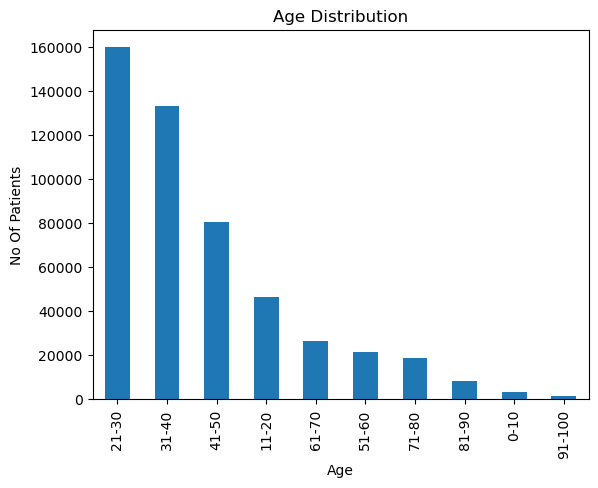

In [20]:
#  Age Distribution

df["Age"].value_counts().plot(kind="bar", title="Age Distribution")
# plt.bar(df["Age"].value_counts().index,df["Age"].value_counts())
# plt.title("Age Distribution")
plt.ylabel("No Of Patients")
# plt.ylabel("Age")
plt.show()

## 📊 Age Distribution Analysis

This graph shows the distribution of patients across different age groups.

### 🔍 Insight:
- Most patients belong to the age group **21–30**
- Indicates higher hospital visits among young adults

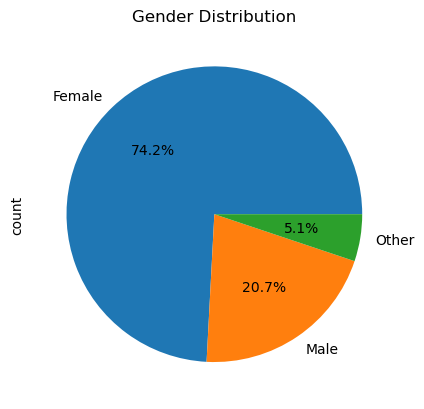

In [21]:
# Gender Distribution
df["gender"].value_counts().plot(kind="pie", autopct="%1.1f%%", title="Gender Distribution")
plt.show()

## 👥 Gender Distribution

This graph represents the proportion of male, female, and other patients.

### 🔍 Insight:
- Majority of patients are **female (~74%)**
- Indicates possible dataset bias or department influence (e.g., gynecology)

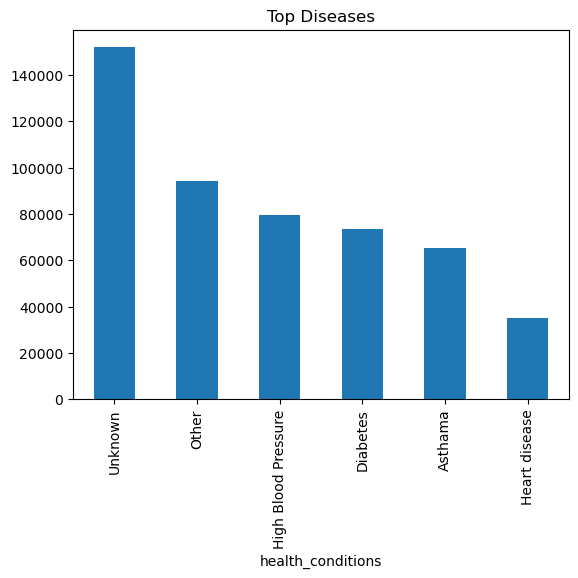

In [25]:
#  Top Diseases

df["health_conditions"].value_counts().plot(kind="bar", title="Top Diseases")
plt.show()

## 🦠 Disease Distribution

This graph shows the frequency of different health conditions.

### 🔍 Insight:
- “Unknown” and “Other” categories are highest  
- The presence of a dominant "Unknown" category indicates missing or incomplete medical records.  
- Common diseases include **high blood pressure and diabetes**

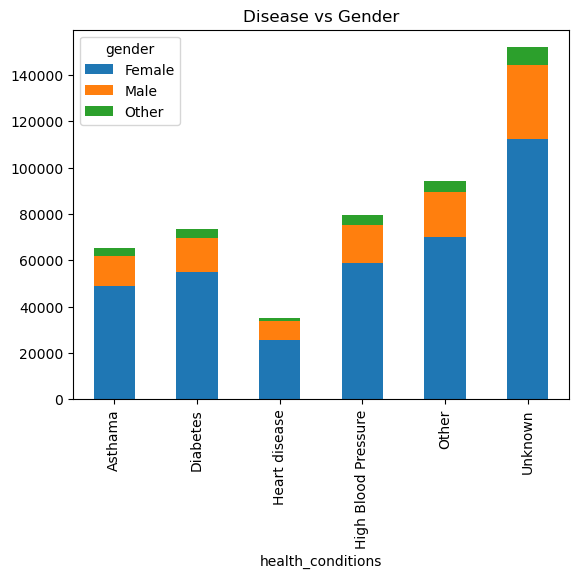

In [26]:
#  Diseases Vs Gender

pd.crosstab(df["health_conditions"], df["gender"]).head(10).plot(kind="bar", stacked=True)
plt.title("Disease vs Gender")
plt.show()

## 👩‍⚕️ Disease vs Gender

This graph compares diseases across genders.

### 🔍 Insight:
- Female patients show higher frequency across most diseases  
- Indicates higher hospital representation of female patients

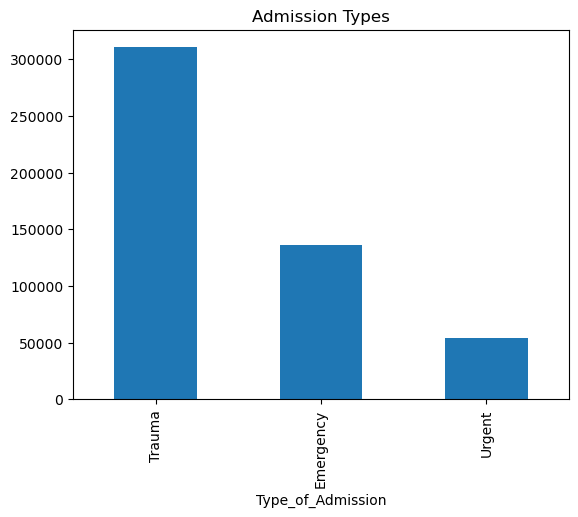

In [27]:
#  Admission Types

df["Type_of_Admission"].value_counts().plot(kind="bar", title="Admission Types")
plt.show()

## 🚑 Admission Type Analysis

This graph shows types of hospital admissions.

### 🔍 Insight:
- **Trauma cases** are the highest
- Followed by emergency and urgent cases
- Indicates many patients come due to critical conditions or accidents

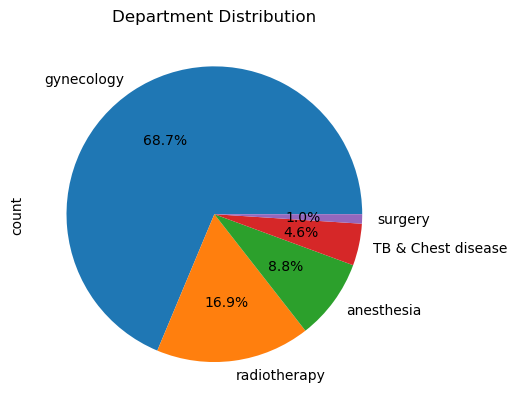

In [28]:
#  Department Distribution 

df["Department"].value_counts().plot(kind="pie",autopct="%1.1f%%", title="Department Distribution")
plt.show()

## 🏥 Department-wise Distribution

This graph shows patient distribution across hospital departments.

### 🔍 Insight:
- **Gynecology** department has highest patient load (~68%)
- Indicates major resource usage in this department

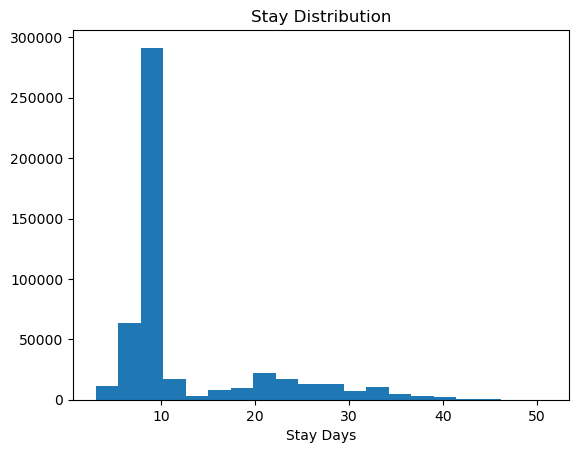

In [29]:
#  Stay

# df["Stay_(in_days)"].plot(kind="hist", bins=20, title="Stay Distribution")
plt.hist(df["Stay_(in_days)"],bins=20)
plt.xlabel("Stay Days")
plt.title("Stay Distribution")
plt.show()

## ⏳ Hospital Stay Distribution

This graph shows how long patients stay in hospital.

### 🔍 Insight:
- Most patients stay **7–10 days**  
- Very few stay beyond 20 days  
- Indicates majority of cases are treated quickly

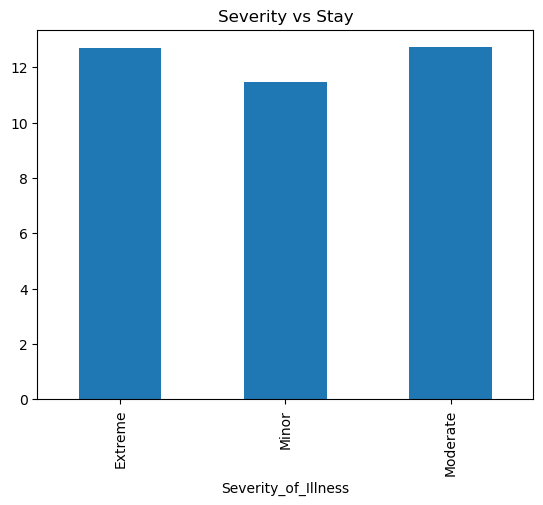

In [30]:
#  Severity and Stay

df.groupby("Severity_of_Illness")["Stay_(in_days)"].mean().plot(kind="bar", title="Severity vs Stay")
plt.show()

## ⚠️ Severity vs Stay

This graph shows how severity affects hospital stay duration.

### 🔍 Insight:
- Moderate and extreme cases have slightly longer stays  
- Indicates increased treatment complexity

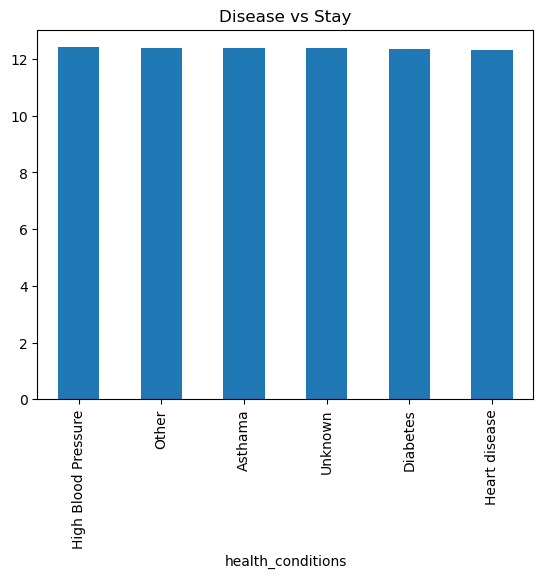

In [31]:
#  Disease And Stay

df.groupby("health_conditions")["Stay_(in_days)"].mean().sort_values(ascending=False).head(10).plot(kind="bar", title="Disease vs Stay")
plt.show()

## 🧠 Disease vs Stay

This graph shows average stay for different diseases.

### 🔍 Insight:
- Stay duration is relatively consistent across diseases  
- Indicates standardized treatment procedures

In [32]:
df.groupby("Severity_of_Illness")["Stay_(in_days)"].mean()

Severity_of_Illness
Extreme     12.686334
Minor       11.454845
Moderate    12.719704
Name: Stay_(in_days), dtype: float64

In [34]:
#  ML MODEL

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [35]:
X = df.drop("Severity_of_Illness", axis=1)
y = df["Severity_of_Illness"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
y_pred = model.predict(X_test)

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.74817


## 🤖 Machine Learning Model

A Random Forest Classifier is used to predict severity of illness.

### 🔍 Key Points:
- Model trained on patient and hospital features  
- Accuracy achieved: **~75%**  
- Predicts severity based on learned patterns  

👉 EDA explains **what happened 📊**  
👉 ML predicts **what will happen 🤖**

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.61      0.67     17602
           1       0.69      0.49      0.57     26442
           2       0.77      0.91      0.83     55956

    accuracy                           0.75    100000
   macro avg       0.73      0.67      0.69    100000
weighted avg       0.74      0.75      0.74    100000



In [41]:
df.to_csv("final_project_data.csv", index=False)

In [42]:
#  Demo Test for ML

sample = X_test.iloc[0]
print(sample)

Available_Extra_Rooms_in_Hospital         2.000000
Department                                2.000000
Ward_Facility_Code                        5.000000
doctor_name                               3.000000
staff_available                           7.000000
patientid                            122397.000000
Age                                       4.000000
gender                                    0.000000
Type_of_Admission                         1.000000
health_conditions                         4.000000
Visitors_with_Patient                     2.000000
Insurance                                 1.000000
Admission_Deposit                      5264.193371
Stay_(in_days)                            9.000000
Name: 104241, dtype: float64


In [43]:
prediction = model.predict(sample.to_frame().T)
print("Predicted Severity:", prediction)

Predicted Severity: [1]


In [44]:
actual = y_test.iloc[0]
print("Actual Severity:", actual)

Actual Severity: 1


In [45]:
df["Severity_of_Illness"].unique()

array([0, 1, 2])

## 🏆 Conclusion

- Identified patterns in patient demographics and hospital data  
- Found relationships between severity, admission, and stay  
- Built a predictive model for severity  

 This project demonstrates how data analysis and machine learning can support better healthcare decision-making.